In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score

import numpy as np
import matplotlib.pyplot as plt

import cv2
from PIL import Image
import json
import os
import random

In [ ]:
!pip install mediapipe

In [ ]:
!mkdir -p /tmp/mediapipe_models
!wget -nc https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite \
  -O /tmp/mediapipe_models/blaze_face_short_range.tflite

In [ ]:

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

face_detector_model_path = '/tmp/mediapipe_models/blaze_face_short_range.tflite'

base_options = python.BaseOptions(model_asset_path=face_detector_model_path)

options = vision.FaceDetectorOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_detection_confidence=0.5
)

detector = vision.FaceDetector.create_from_options(options)

def mask_faces_in_folder(input_root, output_root):
    os.makedirs(output_root, exist_ok=True)

    for root, _, files in os.walk(input_root):
        rel = os.path.relpath(root, input_root)
        save_dir = os.path.join(output_root, rel)
        os.makedirs(save_dir, exist_ok=True)

        for f in files:
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(root, f)
            image = cv2.imread(img_path)
            if image is None:
                continue

            h, w, _ = image.shape

            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            )

            result = detector.detect(mp_image)

            if result.detections:
                for det in result.detections:
                    bbox = det.bounding_box
                    x1 = max(0, bbox.origin_x)
                    y1 = max(0, bbox.origin_y)
                    x2 = min(w, x1 + bbox.width)
                    y2 = min(h, y1 + bbox.height)

                    # Mask face
                    image[y1:y2, x1:x2] = 0

            cv2.imwrite(os.path.join(save_dir, f), image)

train_input_folder = "/content/drive/MyDrive/CAER-S/train"
test_input_folder = "/content/drive/MyDrive/CAER-S/test"

train_output_folder = "/content/ssd_masked/train"
test_output_folder = "/content/ssd_masked/test"

mask_faces_in_folder(train_input_folder, train_output_folder)
mask_faces_in_folder(test_input_folder, test_output_folder)

In [ ]:
MODEL_PATH = "/tmp/mediapipe_models/blaze_face_short_range.tflite"
print("Model exists:", os.path.exists(MODEL_PATH))

In [ ]:
# Paths
src_train = "/content/ssd_masked/train"   # original dataset
src_test  = "/content/ssd_masked/test"
dst_train = "/content/CAERS-ssd/train"             # preprocessed dataset on SSD
dst_test  = "/content/CAERS-ssd/test"

# Image size
IMG_SIZE = 224

# Function to preprocess and save images

def preprocess_and_save(src_folder, dst_folder):
    for emotion in os.listdir(src_folder):
        src_emotion_dir = os.path.join(src_folder, emotion)

        if not os.path.isdir(src_emotion_dir):
            continue

        dst_emotion_dir = os.path.join(dst_folder, emotion)
        os.makedirs(dst_emotion_dir, exist_ok=True)

        for fname in os.listdir(src_emotion_dir):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            src_path = os.path.join(src_emotion_dir, fname)
            dst_path = os.path.join(dst_emotion_dir, fname)

            img = Image.open(src_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img.save(dst_path)

In [ ]:
preprocess_and_save(src_train, dst_train)
preprocess_and_save(src_test, dst_test)

In [ ]:
def display_random_masked_image(output_folder):
    all_masked_images = []
    for root, _, files in os.walk(output_folder):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_masked_images.append(os.path.join(root, f))

    if not all_masked_images:
        print(f"No masked images found in {output_folder}")
        return

    random_image_path = random.choice(all_masked_images)
    print(f"Displaying: {random_image_path}")
    img = cv2.imread(random_image_path)
    if img is not None:
        # OpenCV reads images in BGR, matplotlib expects RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title("Sample Masked Image")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not load image: {random_image_path}")

display_random_masked_image(train_output_folder)

In [ ]:
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
train_dir = "/content/CAERS-ssd/train"
test_dir = "/content/CAERS-ssd/test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,        # IMPORTANT
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Replace final classification layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
EPOCHS = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []

metrics_file = "/content/resnet_metrics.json"

print("Entering training loop")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1} started")

    # ----------------- Training -----------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        if i % 100 == 0:
            print(f"  Training batch {i}/{len(train_loader)}")

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_acc = correct_train / total_train
    train_accuracies.append(train_acc)

    # ----------------- Validation -----------------
    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            if i % 100 == 0:
                print(f"  Eval batch {i}/{len(test_loader)}")

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    val_accuracies.append(acc)
    val_precisions.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] - "
        f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, Val Acc: {acc:.4f}, "
        f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}"
    )

    # ----------------- Save metrics to JSON -----------------
    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_accuracy": train_acc,
        "val_loss": avg_val_loss,
        "val_accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

    try:
        with open(metrics_file, "r") as f:
            all_metrics = json.load(f)
    except FileNotFoundError:
        all_metrics = []

    all_metrics.append(epoch_metrics)

    with open(metrics_file, "w") as f:
        json.dump(all_metrics, f, indent=4)

    # Save model checkpoint
    torch.save(model.state_dict(), "/content/drive/MyDrive/resnet18_emotion_model.pth")

In [ ]:
# Load metrics
metrics_file = "/content/resnet_metrics.json"
with open(metrics_file, "r") as f:
    metrics = json.load(f)

# Extract metrics
epochs = [m['epoch'] for m in metrics]
train_losses = [m['train_loss'] for m in metrics]
val_losses = [m['val_loss'] for m in metrics]
train_accs = [m.get('train_accuracy', None) for m in metrics]
val_accs = [m['val_accuracy'] for m in metrics]
val_f1s = [m['f1_score'] for m in metrics]

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
if all(train_accs):
    plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Plot F1-Score
plt.figure(figsize=(10, 5))
plt.plot(epochs, val_f1s, label="Validation F1-Score", marker='o', color='purple')
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("Validation F1-Score vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!cp -r /content/drive/MyDrive/CAER-S /content/CAER-S

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


num_classes = 7  # MUST match training

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [ ]:
state_dict = torch.load(
    "/content/drive/MyDrive/resnet18_emotion_model.pth",
    map_location=device
)

model.load_state_dict(state_dict)
model.eval()

In [ ]:
predict_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = predict_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, 1)

    predicted_class = class_names[pred_idx.item()]
    confidence = confidence.item()

    return predicted_class, confidence

In [ ]:
class_names = [
    "Angry", "Disgust", "Fear",
    "Happy", "Neutral", "Sad", "Surprise"
]

img_path = "/content/drive/MyDrive/CAER-S/test/Sad/2967.png"

label, confidence = predict_image(
    img_path
)

print(f"Prediction: {label} ({confidence*100:.2f}%)")

In [ ]:
def show_original_and_masked(original_path, masked_path):
    orig = Image.open(original_path).convert("RGB")
    masked = Image.open(masked_path).convert("RGB")

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(masked)
    plt.title("Masked")
    plt.axis("off")

    plt.show()

Prediction: Sad (35.57%)


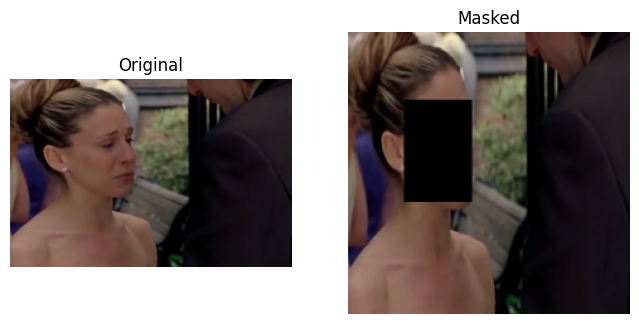

In [ ]:
orig_img = "/content/drive/MyDrive/CAER-S/test/Sad/2967.png"
masked_img = "/content/CAERS-ssd/test/Sad/2967.png"

print(f"Prediction: {label} ({confidence*100:.2f}%)")

show_original_and_masked(orig_img, masked_img)
